In [1]:
!pip install shap transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [4]:
import zipfile
import os

zip_path = "/content/bert-phishing-model.zip"
extract_path = "/content/bert-phishing-model"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Model unzipped successfully!")
print("Contents:", os.listdir(extract_path))

Model unzipped successfully!
Contents: ['special_tokens_map.json', 'config.json', 'tokenizer_config.json', 'vocab.txt', 'model.safetensors']


In [5]:
!pip uninstall -y shap numpy
!pip install numpy==1.26.4
!pip install shap==0.44.1

Found existing installation: shap 0.48.0
Uninstalling shap-0.48.0:
  Successfully uninstalled shap-0.48.0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 104.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.8/535.8 kB 35.2 MB/s eta 0:00:00
  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.8
    Uninstalling slicer-0.0.8:
      Successfully uninstalled slicer-0.0.8


In [2]:
import shap, numpy as np
import torch, pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification

model_path = "/content/bert-phishing-model"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path).eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_proba_shap(texts):
    if isinstance(texts, np.ndarray): texts = texts.tolist()
    if isinstance(texts, str): texts = [texts]
    enc = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=128)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    return probs

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba_shap, masker, output_names=["Benign","Phish"])

df = pd.read_csv("/content/combined_featured_dataset_new.csv", encoding='latin-1')
sample_texts = df['Clean_Message'].dropna().sample(5, random_state=42).tolist()

shap_values = explainer(sample_texts)

for i in range(len(sample_texts)):
    print(f"\n--- Email {i+1} ---")
    shap.plots.text(shap_values[i])

`encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
`encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
`encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
`encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
PartitionExplainer explainer: 6it [00:18,  4.65s/it]


--- Email 1 ---



--- Email 2 ---



--- Email 3 ---



--- Email 4 ---



--- Email 5 ---


In [ ]:
for i, val in enumerate(shap_values):
    html_str = shap.plots.text(val, display=False)
    with open(f"shap_explanation_{i}.html", "w", encoding="utf-8") as f:
        f.write(html_str)

from google.colab import files
files.download("shap_explanation_0.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import numpy as np


sample_df = df.sample(200, random_state=42)
texts = sample_df['Clean_Message'].tolist()
labels = sample_df['label'].tolist()

shap_values = explainer(texts)

Token indices sequence length is longer than the specified maximum sequence length for this model (1356 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▎         | 5/200 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  16%|█▋        | 33/200 [01:57<09:51,  3.54s/it]

...

PartitionExplainer explainer:  98%|█████████▊| 196/200 [16:46<00:18,  4.51s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  99%|█████████▉| 198/200 [16:55<00:09,  4.64s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 201it [17:07,  5.24s/it]


In [7]:
from collections import defaultdict
import numpy as np

word_importance = defaultdict(float)

for i in range(len(shap_values)):
    if labels[i] == 1:
        tokens = shap_values.data[i]
        contributions = shap_values.values[i]

        if contributions.ndim > 1:
            contributions = contributions[:, 1]

        for token, contribution in zip(tokens, contributions):
            word_importance[token] += abs(float(contribution))

sorted_words = sorted(word_importance.items(), key=lambda x: x[1], reverse=True)[:20]




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



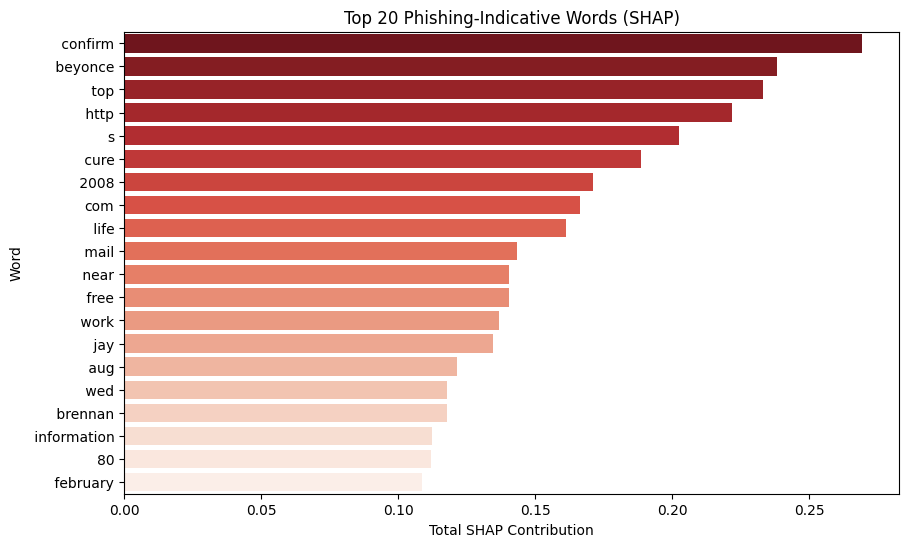

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

phish_df = pd.DataFrame(sorted_words, columns=['Word', 'Importance'])

plt.figure(figsize=(10,6))
sns.barplot(data=phish_df, x='Importance', y='Word', palette='Reds_r')
plt.title("Top 20 Phishing-Indicative Words (SHAP)")
plt.xlabel("Total SHAP Contribution")
plt.ylabel("Word")
plt.show()

In [9]:
import shap, numpy as np
import torch, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

df = pd.read_csv("/content/combined_featured_dataset_new.csv", encoding='latin-1')
sample_df = df.sample(200, random_state=42)
texts = sample_df['Clean_Message'].tolist()
labels = sample_df['label'].tolist()

shap_values = explainer(texts)

word_importance_phish = defaultdict(float)
word_importance_benign = defaultdict(float)

for i in range(len(shap_values)):
    tokens = shap_values.data[i]
    contributions = shap_values.values[i]

    if contributions.ndim > 1:
        contrib_phish = contributions[:, 1]
        contrib_benign = contributions[:, 0]
    else:
        continue

    if labels[i] == 1:
        for token, contribution in zip(tokens, contrib_phish):
            word_importance_phish[token] += abs(float(contribution))

    elif labels[i] == 0:
        for token, contribution in zip(tokens, contrib_benign):
            word_importance_benign[token] += abs(float(contribution))


top_phish_words = sorted(word_importance_phish.items(), key=lambda x: x[1], reverse=True)[:20]
top_benign_words = sorted(word_importance_benign.items(), key=lambda x: x[1], reverse=True)[:20]


phish_df = pd.DataFrame(top_phish_words, columns=['Word', 'Importance'])
benign_df = pd.DataFrame(top_benign_words, columns=['Word', 'Importance'])

`encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▎         | 5/200 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  15%|█▌        | 30/200 [01:42<10:36,  3.74s/it]

...

PartitionExplainer explainer:  98%|█████████▊| 196/200 [16:42<00:18,  4.50s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  99%|█████████▉| 198/200 [16:52<00:09,  4.64s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 201it [17:03,  5.22s/it]




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



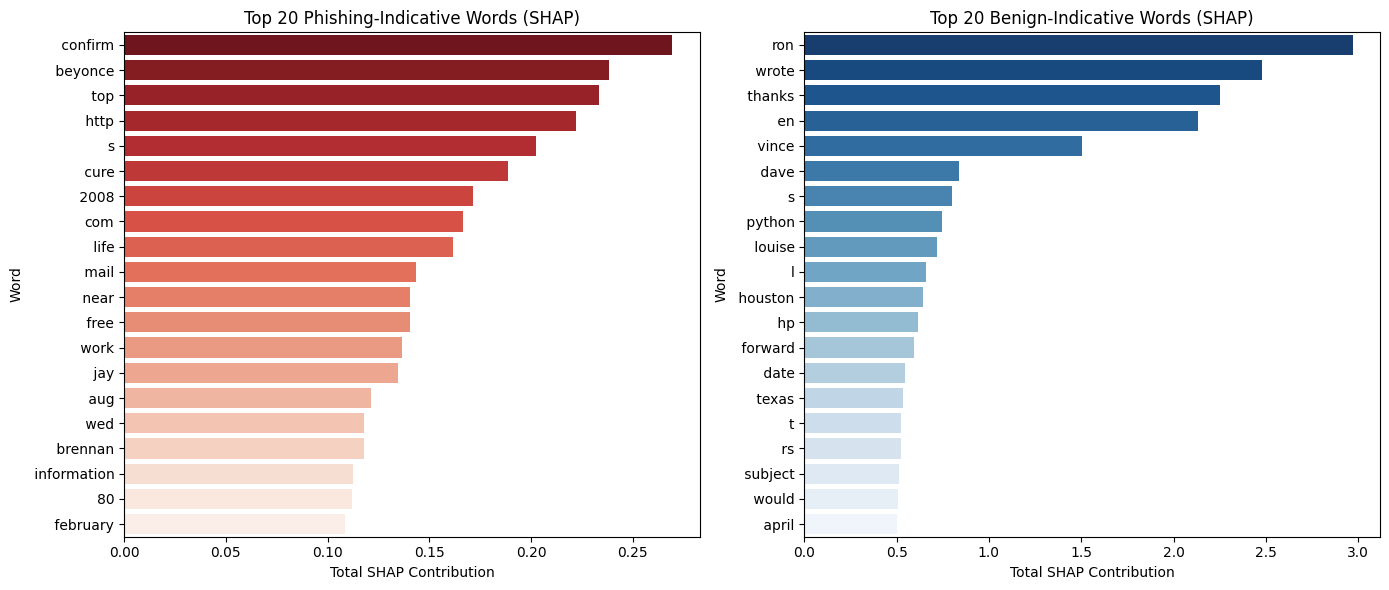

In [10]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=phish_df, x='Importance', y='Word', palette='Reds_r')
plt.title("Top 20 Phishing-Indicative Words (SHAP)")
plt.xlabel("Total SHAP Contribution")
plt.ylabel("Word")

plt.subplot(1, 2, 2)
sns.barplot(data=benign_df, x='Importance', y='Word', palette='Blues_r')
plt.title("Top 20 Benign-Indicative Words (SHAP)")
plt.xlabel("Total SHAP Contribution")
plt.ylabel("Word")

plt.tight_layout()
plt.show()